# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Dziarur Rahman]
- **Email:** [dziarurr@gmail.com]
- **ID Dicoding:** [cdcc283d6y0311]

## Menentukan Pertanyaan Bisnis

- 1. Berapa persentase pelanggan yang melakukan pembelian ulang (repeat order) dalam periode tahun 2016–2018, dan bagaimana hasil tersebut dapat digunakan untuk mengevaluasi tingkat loyalitas pelanggan?
- 2. Berapa rata-rata rating produk dan bagaimana perbandingan rating antar kategori produk dalam periode tahun 2016–2018 untuk mengidentifikasi kategori dengan performa terbaik dan terburuk?

## Import Semua Packages/Library yang Digunakan

In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [236]:
orders = pd.read_csv("orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [237]:
customers = pd.read_csv("customers_dataset.csv")
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [238]:
reviews = pd.read_csv("order_reviews_dataset.csv")
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [239]:
items = pd.read_csv("order_items_dataset.csv")
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [240]:
product = pd.read_csv("products_dataset.csv")
product.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- xxx
- xxx

### Assessing Data

In [241]:
## Cek Dataset orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [242]:
orders.nunique()

,0
order_id,99441
customer_id,99441
order_status,8
order_purchase_timestamp,98875
order_approved_at,90733
order_delivered_carrier_date,81018
order_delivered_customer_date,95664
order_estimated_delivery_date,459


In [243]:
print("Jumlah duplikasi: ", orders.duplicated().sum())

Jumlah duplikasi:  0


In [244]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [245]:
## Cek dataset customers
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [246]:
customers.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [247]:
print("Jumlah duplikasi: ", customers.duplicated().sum())

Jumlah duplikasi:  0


In [248]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [249]:
## Cek dataset reviews
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [250]:
reviews.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [251]:
print("Jumlah duplikasi: ", reviews.duplicated().sum())

Jumlah duplikasi:  0


In [252]:
reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [253]:
## Cek Dataset Items
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [254]:
items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [255]:
print("Jumlah duplikasi: ", items.duplicated().sum())

Jumlah duplikasi:  0


In [256]:
items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [257]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [258]:
product.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [259]:
print("Jumlah Duplikasi: ", product.duplicated().sum())

Jumlah Duplikasi:  0


In [260]:
product.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- xxx
- xxx

### Cleaning Data

In [261]:
## Membersihkan dataset orders
orders_clean = orders[orders['order_status'] == 'delivered']
orders_clean.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


In [262]:
orders_clean = orders_clean.drop(columns=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
orders_clean.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0


In [263]:
## Membersihkan dataset reviews
reviews_clean = reviews.drop(columns=['review_comment_title', 'review_comment_message'])
reviews_clean.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


In [264]:
## Membersihkan daatset product
product_clean = product[['product_id', 'product_category_name']]
product['product_category_name'] = product['product_category_name'].fillna('unknown')
product_clean.isna().sum()

,0
product_id,0
product_category_name,610


**Insight:**
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore ...

In [265]:
df = (
    orders[['order_id', 'customer_id', 'order_purchase_timestamp']]
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
    .merge(reviews[['order_id', 'review_score']], on='order_id')
    .merge(items[['order_id', 'product_id']], on='order_id')
    .merge(product[['product_id', 'product_category_name']], on='product_id')
)

In [266]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df = df[
    (df['order_purchase_timestamp'] >= '2016' ) &
    (df['order_purchase_timestamp'] <= '2018' )
]

In [267]:
# hitung jumlah order unik per customer
repeat = df.groupby('customer_unique_id')['order_id'].nunique()

# hitung jumlah pelanggan yang melakukan repeat order
repeat_rate = (repeat > 1).sum() / repeat.count()

print("Repeat Rate: ", repeat_rate)

Repeat Rate:  0.02828484062268347


In [268]:
# rata-rata rating
avg_rating = df['review_score'].mean()

print("Average Rating:", avg_rating)

Average Rating: 4.0474989737876035


In [269]:
rating_kategori = (
    df.groupby('product_category_name')['review_score']
    .mean()
    .sort_values()
)

In [270]:
# Mengambil data yang diperlukan
df_download = df[
    [
        'customer_unique_id',
        'order_id',
        'review_score',
        'product_category_name',
        'order_purchase_timestamp'
    ]
]

In [271]:
# Menghilangkan data duplikasi
df_download = df_download.drop_duplicates()

In [272]:
# handle data missing
df_download['product_category_name'] = df_download['product_category_name'].fillna('unknown')

In [273]:
# Cek hasil
print("Shape: ", df_download.shape)
df_download.head(10000)

Shape:  (44984, 5)


,customer_unique_id,order_id,review_score,product_category_name,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,4,utilidades_domesticas,2017-10-02 10:56:33
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,5,pet_shop,2017-11-18 19:28:06
5,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,4,automotivo,2017-07-09 21:57:05
6,36edbb3fb164b1f16485364b6fb04c73,136cce7faa42fdb2cefd53fdc79a6098,2,unknown,2017-04-11 12:22:08
7,932afa1e708222e5821dac9cd5db4cae,6514b8ad8028c9f2cc2374ded245783f,5,automotivo,2017-05-16 13:10:30
...,...,...,...,...,...
24915,d9997a7f31ab2f0e410be938a3d251fa,86795953649e4ff4f2edada496f38e6c,2,pet_shop,2017-08-13 12:45:38
24922,56f162881887b4fd9176b338ac8ff2d0,3f741f27f2dd8988d7c287f567a35c52,4,moveis_decoracao,2017-05-30 17:52:25
24924,506a8f8461c08d84d2198b3bd9a5bd9a,17c80e00cb0e561fc779745fae6dc4e9,5,brinquedos,2017-11-26 13:04:06
24925,be76b702c8a7f76b6d8984f7fb83d7ce,f3458c2495b179f0e198030eb89b8ab5,3,brinquedos,2017-10-30 16:57:04


In [274]:
# Mengecilkan data menggunakan Random Sampling
df_download = df_download.sample(n=50000, random_state=42, replace=True)

In [275]:
## Simpan all data
df_download.to_csv('all_data.csv', index=False)

In [276]:
# Simpan data customers
customers.to_csv('customers_clean.csv', index=False)

In [277]:
# Simpan data orders
orders_clean = orders_clean.head(10000)
orders_clean.to_csv('orders_clean.csv', index=False)

In [278]:
# Simpan data reviews
reviews_clean = reviews_clean.head(10000)
reviews_clean.to_csv('reviews_clean.csv', index=False)

In [279]:
# Simpan data items
items = items.head(10000)
items.to_csv('items_clean.csv', index=False)

In [280]:
# Simpan data product
product_clean = product_clean.head(10000)
product_clean.to_csv('product_clean.csv', index=False)

**Insight:**
- xxx
- xxx

## Visualization & Explanatory Analysis

### Pertanyaan 1:

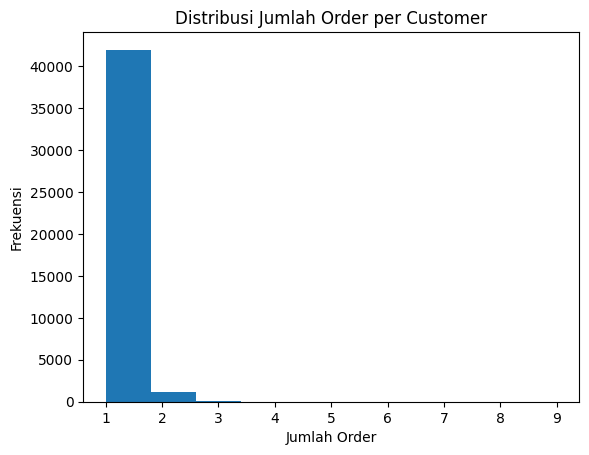

In [281]:
# Visualisasi Bar Chart
repeat = df.groupby('customer_unique_id')['order_id'].nunique()

plt.hist(repeat, bins=10)
plt.title("Distribusi Jumlah Order per Customer")
plt.xlabel("Jumlah Order")
plt.ylabel("Frekuensi")
plt.show()

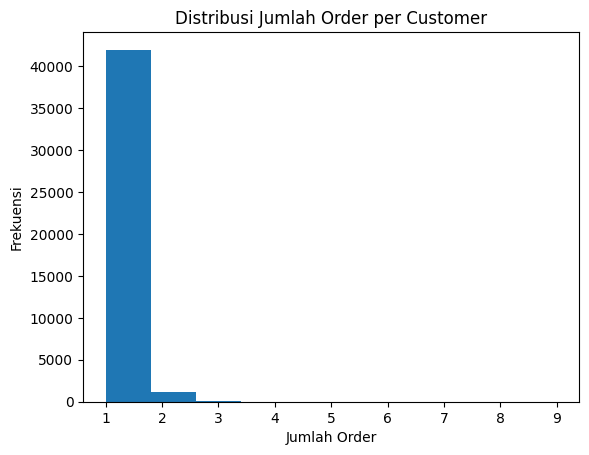

In [282]:
repeat = df.groupby('customer_unique_id')['order_id'].nunique()

plt.hist(repeat, bins=10)
plt.title("Distribusi Jumlah Order per Customer")
plt.xlabel("Jumlah Order")
plt.ylabel("Frekuensi")
plt.show()

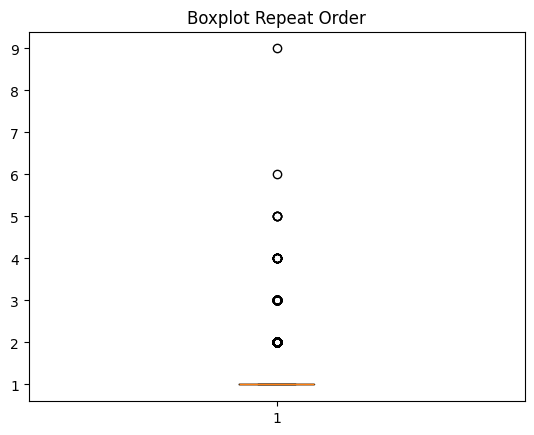

In [283]:
# Visualisasi Box Plot
plt.boxplot(repeat)
plt.title("Boxplot Repeat Order")
plt.show()

### Pertanyaan 2:

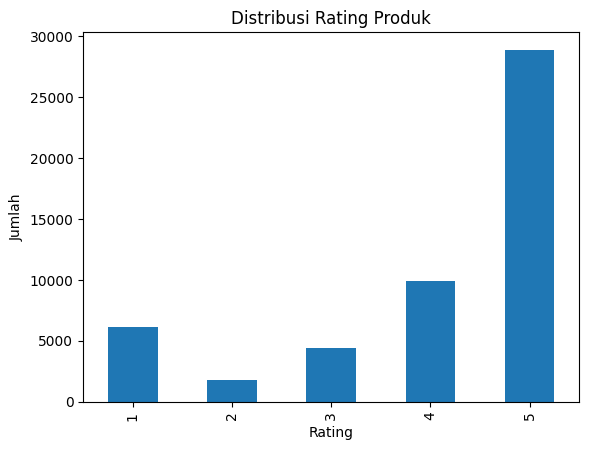

In [284]:
# Visualisasi distribusi rating
fig, ax = plt.subplots()
df['review_score'].value_counts().sort_index().plot(kind='bar', ax=ax)

ax.set_title("Distribusi Rating Produk")
ax.set_xlabel("Rating")
ax.set_ylabel("Jumlah")

plt.show()

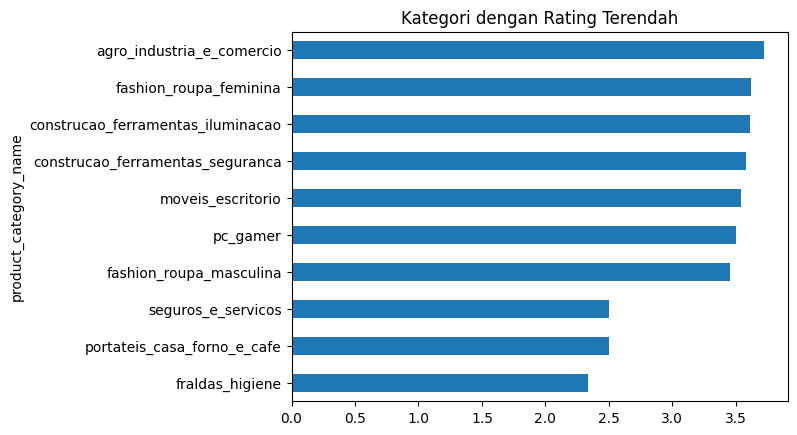

In [285]:
# Visulisasi rating per kategori
fig, ax = plt.subplots()
rating_kategori.head(10).plot(kind='barh', ax=ax)

ax.set_title("Kategori dengan Rating Terendah")

plt.show()

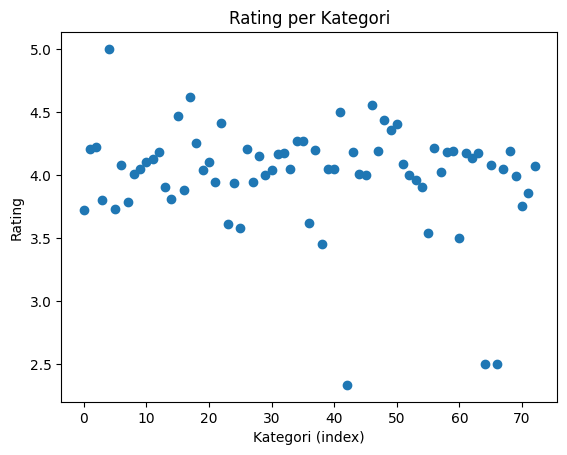

In [286]:
rating_kategori = df.groupby('product_category_name')['review_score'].mean().reset_index()

plt.scatter(range(len(rating_kategori)), rating_kategori['review_score'])
plt.title("Rating per Kategori")
plt.xlabel("Kategori (index)")
plt.ylabel("Rating")
plt.show()

**Insight:**
- xxx
- xxx

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1

Berdasarkan hasil analisis eksploratif, distribusi jumlah pembelian menunjukkan bahwa sebagian besar pelanggan hanya melakukan satu kali transaksi. Hal ini didukung oleh nilai repeat order rate yang relatif rendah, yang mengindikasikan bahwa tingkat loyalitas pelanggan masih belum optimal.

Visualisasi histogram memperlihatkan dominasi pelanggan dengan satu kali pembelian, sementara boxplot menunjukkan adanya sejumlah kecil pelanggan dengan frekuensi pembelian tinggi sebagai outlier. Dengan demikian, dapat disimpulkan bahwa mayoritas pelanggan belum melakukan pembelian ulang secara konsisten.
- Conclution pertanyaan 2

Berdasarkan hasil analisis, rata-rata rating produk menunjukkan nilai yang relatif tinggi, yang mengindikasikan bahwa secara umum pelanggan merasa puas terhadap produk yang dibeli.

Visualisasi histogram menunjukkan bahwa sebagian besar rating berada pada nilai tinggi, sedangkan boxplot mengindikasikan bahwa sebaran rating cukup terkonsentrasi tanpa banyak outlier ekstrem. Namun, analisis lebih lanjut pada tingkat kategori produk menunjukkan adanya variasi rating antar kategori, di mana beberapa kategori memiliki nilai lebih rendah dibandingkan yang lain.

Hal ini menunjukkan bahwa meskipun kepuasan pelanggan secara keseluruhan baik, masih terdapat peluang perbaikan pada kategori produk tertentu.